In [1]:
from steiner_solution import adjust_polygon_perimeter, inputs, minimiseCostWithAnnotations
from solution_zub_and_zlb import get_zub_zlb
from subgradient_lambda import update_lambda
from data_store_csv import write_to_csv
import numpy as np
import random

Adjusted Points:
[[0.04025555 0.04025555]
 [0.08051109 0.28178884]
 [0.20127774 0.20127774]
 [0.32204438 0.20127774]
 [0.40255548 0.12076664]
 [0.1610222  0.04025555]]
Total Perimeter: 0.9999999979740497


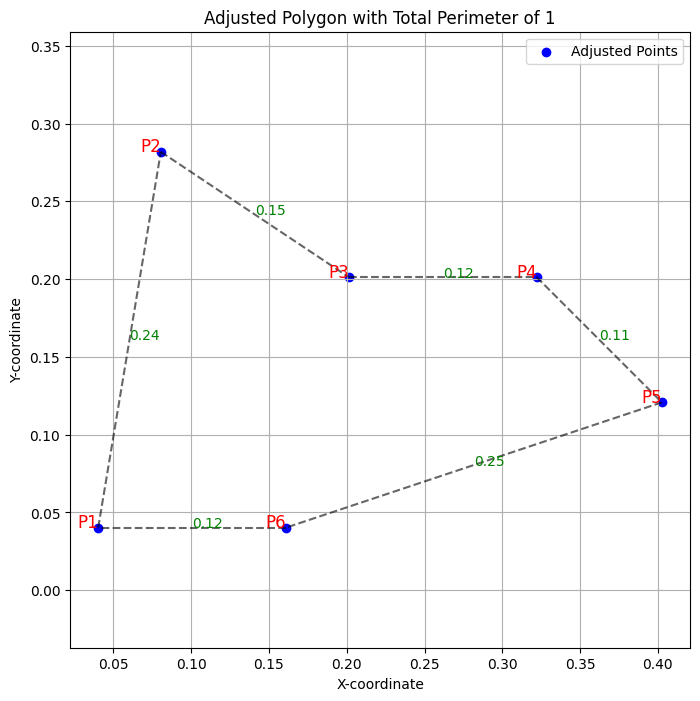

[(0.0402555463512678, 0.0402555463512678), (0.0805110927025356, 0.28178883731433374), (0.20127774461179818, 0.20127774461179818), (0.32204438366560156, 0.20127774461179818), (0.40255547636813716, 0.12076663905380339), (0.16102219826053038, 0.0402555463512678)]
lambd value as input [1, 1, 1, 1, 1, 1]
source---------------------------------------  [0]
destination-----------------------------------------------  [2]
---------------- Iteration 0 Lambda_n [1, 1, 1, 1, 1, 1] ----------------
---------------- Iteration 0 ----------------
[(0.0402555463512678, 0.0402555463512678), (0.0805110927025356, 0.28178883731433374), (0.20127774461179818, 0.20127774461179818), (0.32204438366560156, 0.20127774461179818), (0.40255547636813716, 0.12076663905380339), (0.16102219826053038, 0.0402555463512678)]

----------------------in solution 1a ZUB----------------

[(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)]
nodes : [0, 1, 2, 3, 4, 5]
arcs : [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)]
time : {(0, 

KeyboardInterrupt: 

In [9]:
def get_new_lambda(lambda_n, fij, yij, zub, zlb, n):
    lambda_new, theta_n, s_lambda = update_lambda(lambda_n, fij, yij, zub, zlb, n)
    return lambda_new, theta_n, s_lambda

# Example input points (initial polygon)
input_points = [(0.03131397,0.03131397),(0.06262794,0.2191978 ),(0.15656986,0.15656986),(0.25051177,0.15656986), (0.31313971,0.09394191),
                (0.12525589,0.03131397)]
adjusted_points, total_perimeter = adjust_polygon_perimeter(input_points)
edges_input = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)]
inputs(adjusted_points,total_perimeter, edges_input)

# Convert the points to a list of tuples
optimized_points = [tuple(point) for point in adjusted_points]
print(optimized_points) 

station_cost = 1
steiner_cost = 6
edge_cost = 10

# cost, solution_x, solution_y, selected_edges = minimiseCostWithAnnotations(optimized_points, station_cost, steiner_cost, edge_cost)
# points_for_zlb_zub = [(solution_x[i], solution_y[i]) for i in range(len(solution_x))]

cost = station_cost #this is dummy currently for testing actaully its the cost from the steiner tree solution

points_for_zlb_zub = optimized_points
selected_edges = edges_input

lambda_n = [1 for i in selected_edges]
print("lambd value as input", lambda_n)

speed = 30
capacity = 1000
alpha = 0.5
beta = 0.5
demand = 500
stop_criteria = 1e-6
n = 0
source = [0]
destination = [2]

src_dest = [(0, 1)]

print("source--------------------------------------- ", source)
print("destination----------------------------------------------- ", destination)
data = []
theta_n = 0
s_lambda = 0

while True:
    print(f"---------------- Iteration {n} Lambda_n {lambda_n} ----------------")
    
    print(f"---------------- Iteration {n} ----------------")
    zub, zlb, fij, yij = get_zub_zlb(points_for_zlb_zub, station_cost, steiner_cost, edge_cost, lambda_n, speed, capacity, demand, alpha, beta, source, destination, cost, selected_edges, src_dest)
    
    gap = zub - zlb

    print()
    print(f"---------------- Iteration {n} ----------------")
    print(f"ZLB: {zlb}")
    print(f"ZUB: {zub}")
    print(f"GAP: {gap}")

    iteration_wise_data = {"Iteration":n, "ZLB":zlb, "ZUB":zub, "GAP":gap, "Lambda":lambda_n, "theta_n":theta_n, "fij":fij, "yij":yij, "s_lambda":s_lambda}
    data.append(iteration_wise_data)
    write_to_csv(data)
    print(f"------------------------------------------------")
    print()
    
    if gap <= stop_criteria:
        print("------------- Stopping Criteria Met ------------")
        print(f"Iterations: {n}")
        print(f"Final ZLB: {zlb}")
        print(f"Final ZUB: {zub}")
        print(f"Final GAP: {gap}")
        final_data = {"Iteration":f"Final Iteration:{n}", "ZLB":f"{zlb}", "ZUB":f"{zub}", "GAP":f"{gap}", "Lambda":lambda_n, "theta_n":theta_n, "fij":fij, "yij":yij, "s_lambda":s_lambda}
        data.append(final_data)
        break
    else:
        n += 1
        print(f"Iteration {n}: Lambda before update: {lambda_n}")

        lambda_n, s_lambda, theta_n = get_new_lambda(lambda_n, fij, yij, zub, zlb, n)
        
        print(f"Iteration {n}: Lambda after update: {lambda_n}")

write_to_csv(data)

Adjusted Points:
[[0.08657937 0.        ]
 [0.14429896 0.        ]
 [0.14429896 0.02885979]
 [0.14429896 0.08657937]
 [0.08657937 0.08657937]
 [0.02885979 0.08657937]
 [0.02885979 0.05771958]
 [0.02885979 0.11543917]
 [0.08657937 0.11543917]
 [0.11543917 0.11543917]
 [0.14429896 0.11543917]
 [0.11543917 0.14429896]
 [0.05771958 0.14429896]
 [0.11543917 0.17315875]
 [0.11543917 0.20201854]
 [0.08657937 0.20201854]
 [0.         0.20201854]
 [0.         0.17315875]
 [0.         0.11543917]]
Total Perimeter: 0.9999998926092625


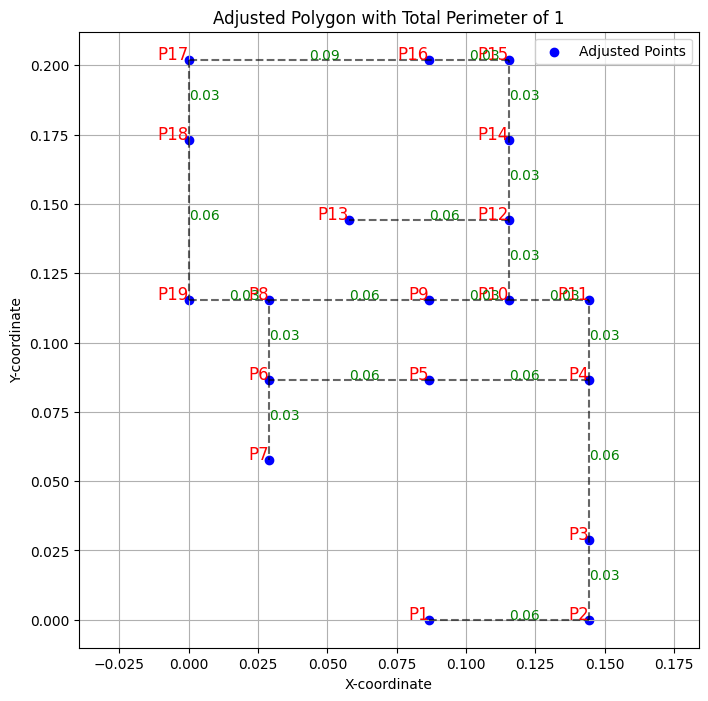

[(0.08657937380322922, 0.0), (0.14429895633871537, 0.0), (0.14429895633871537, 0.028859791267743073), (0.14429895633871537, 0.08657937380322922), (0.08657937380322922, 0.08657937380322922), (0.028859791267743073, 0.08657937380322922), (0.028859791267743073, 0.05771958253548615), (0.028859791267743073, 0.1154391650709723), (0.08657937380322922, 0.1154391650709723), (0.1154391650709723, 0.1154391650709723), (0.14429895633871537, 0.1154391650709723), (0.1154391650709723, 0.14429895633871537), (0.05771958253548615, 0.14429895633871537), (0.1154391650709723, 0.17315874760645844), (0.1154391650709723, 0.20201853887420151), (0.08657937380322922, 0.20201853887420151), (0.0, 0.20201853887420151), (0.0, 0.17315874760645844), (0.0, 0.1154391650709723)]
lambd value as input [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
source---------------------------------------  [0]
destination-----------------------------------------------  [2]
---------------- Iteration 0 Lambda_n [1, 1, 1, 1, 

KeyboardInterrupt: 

In [10]:
def get_new_lambda(lambda_n, fij, yij, zub, zlb, n):
    lambda_new, theta_n, s_lambda = update_lambda(lambda_n, fij, yij, zub, zlb, n)
    return lambda_new, theta_n, s_lambda

# Example input points (initial polygon)
input_points = [(3,0),(5,0), (5,1), (5,3), (3,3), (1,3), (1,2), (1, 4), (3,4), (4,4), (5,4), (4,5), (2,5), (4,6), (4,7), (3,7), (0,7), (0,6), (0,4)]
adjusted_points, total_perimeter = adjust_polygon_perimeter(input_points)
edges_input = [(0, 1), (1,2), (2,3), (3, 4), (3, 10), (4, 5), (5, 6), (5, 7), (7, 8), (8, 9), (9, 10), (9, 11), (11, 12), (11, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18), (18, 7)]
inputs(adjusted_points,total_perimeter, edges_input)

# Convert the points to a list of tuples
optimized_points = [tuple(point) for point in adjusted_points]
print(optimized_points) 

station_cost = 1
steiner_cost = 6
edge_cost = 10

# cost, solution_x, solution_y, selected_edges = minimiseCostWithAnnotations(optimized_points, station_cost, steiner_cost, edge_cost)
# points_for_zlb_zub = [(solution_x[i], solution_y[i]) for i in range(len(solution_x))]

cost = station_cost #this is dummy currently for testing actaully its the cost from the steiner tree solution

points_for_zlb_zub = optimized_points
selected_edges = edges_input

lambda_n = [1 for i in selected_edges]
print("lambd value as input", lambda_n)

speed = 30
capacity = 1000
alpha = 0.5
beta = 0.5
demand = 500
stop_criteria = 1e-6
n = 0
source = [0]
destination = [2]

src_dest = [(0, 1)]

print("source--------------------------------------- ", source)
print("destination----------------------------------------------- ", destination)
data = []
theta_n = 0
s_lambda = 0

while True:
    print(f"---------------- Iteration {n} Lambda_n {lambda_n} ----------------")
    
    print(f"---------------- Iteration {n} ----------------")
    zub, zlb, fij, yij = get_zub_zlb(points_for_zlb_zub, station_cost, steiner_cost, edge_cost, lambda_n, speed, capacity, demand, alpha, beta, source, destination, cost, selected_edges, src_dest)
    
    gap = zub - zlb

    print()
    print(f"---------------- Iteration {n} ----------------")
    print(f"ZLB: {zlb}")
    print(f"ZUB: {zub}")
    print(f"GAP: {gap}")

    iteration_wise_data = {"Iteration":n, "ZLB":zlb, "ZUB":zub, "GAP":gap, "Lambda":lambda_n, "theta_n":theta_n, "fij":fij, "yij":yij, "s_lambda":s_lambda}
    data.append(iteration_wise_data)
    write_to_csv(data)
    print(f"------------------------------------------------")
    print()
    
    if gap <= stop_criteria:
        print("------------- Stopping Criteria Met ------------")
        print(f"Iterations: {n}")
        print(f"Final ZLB: {zlb}")
        print(f"Final ZUB: {zub}")
        print(f"Final GAP: {gap}")
        final_data = {"Iteration":f"Final Iteration:{n}", "ZLB":f"{zlb}", "ZUB":f"{zub}", "GAP":f"{gap}", "Lambda":lambda_n, "theta_n":theta_n, "fij":fij, "yij":yij, "s_lambda":s_lambda}
        data.append(final_data)
        break
    else:
        n += 1
        print(f"Iteration {n}: Lambda before update: {lambda_n}")

        lambda_n, s_lambda, theta_n = get_new_lambda(lambda_n, fij, yij, zub, zlb, n)
        
        print(f"Iteration {n}: Lambda after update: {lambda_n}")

write_to_csv(data)

Adjusted Points:
[[0.        0.       ]
 [0.1545085 0.309017 ]
 [0.309017  0.       ]]
Total Perimeter: 1.000000005120445


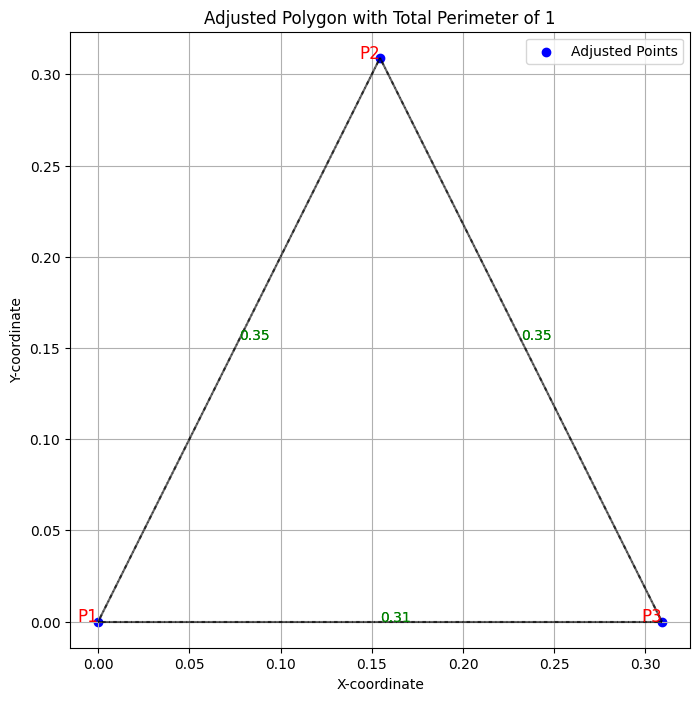

[(0.0, 0.0), (0.15450849797862598, 0.30901699595725196), (0.30901699595725196, 0.0)]
lambd value as input [1, 1, 1, 1, 1, 1]
source---------------------------------------  [0]
destination-----------------------------------------------  [2]
---------------- Iteration 0 Lambda_n [1, 1, 1, 1, 1, 1] ----------------
---------------- Iteration 0 ----------------
[(0.0, 0.0), (0.15450849797862598, 0.30901699595725196), (0.30901699595725196, 0.0)]

----------------------in solution 1a ZUB----------------

[(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]
nodes : [0, 1, 2]
arcs : [(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]
time : {(0, 1): 0.011516383486053217, (0, 2): 0.010300566531908398, (1, 0): 0.011516383486053217, (1, 2): 0.011516383486053217, (2, 0): 0.010300566531908398, (2, 1): 0.011516383486053217}
cost : {(0, 1): 3.454915045815965, (0, 2): 3.0901699595725196, (1, 0): 3.454915045815965, (1, 2): 3.454915045815965, (2, 0): 3.0901699595725196, (2, 1): 3.454915045815965}
demand : 500


KeyboardInterrupt: 

In [5]:
def get_new_lambda(lambda_n, fij, yij, zub, zlb, n):
    lambda_new, theta_n, s_lambda = update_lambda(lambda_n, fij, yij, zub, zlb, n)
    return lambda_new, theta_n, s_lambda

# Example input points (initial polygon)
input_points = [(0,0),(1,2), (2,0)]
adjusted_points, total_perimeter = adjust_polygon_perimeter(input_points)
edges_input = [(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]
inputs(adjusted_points,total_perimeter, edges_input)

# Convert the points to a list of tuples
optimized_points = [tuple(point) for point in adjusted_points]
print(optimized_points) 

station_cost = 1
steiner_cost = 6
edge_cost = 10

# cost, solution_x, solution_y, selected_edges = minimiseCostWithAnnotations(optimized_points, station_cost, steiner_cost, edge_cost)
# points_for_zlb_zub = [(solution_x[i], solution_y[i]) for i in range(len(solution_x))]

cost = station_cost #this is dummy currently for testing actaully its the cost from the steiner tree solution

points_for_zlb_zub = optimized_points
selected_edges = edges_input

lambda_n = [1 for i in selected_edges]
print("lambd value as input", lambda_n)

speed = 30
capacity = 1000
alpha = 0.5
beta = 0.5
demand = 500
stop_criteria = 1e-6
n = 0
source = [0]
destination = [2]

src_dest = [(0, 1)]

print("source--------------------------------------- ", source)
print("destination----------------------------------------------- ", destination)
data = []
theta_n = 0
s_lambda = 0

while True:
    print(f"---------------- Iteration {n} Lambda_n {lambda_n} ----------------")
    
    print(f"---------------- Iteration {n} ----------------")
    zub, zlb, fij, yij = get_zub_zlb(points_for_zlb_zub, station_cost, steiner_cost, edge_cost, lambda_n, speed, capacity, demand, alpha, beta, source, destination, cost, selected_edges, src_dest)
    
    gap = zub - zlb

    print()
    print(f"---------------- Iteration {n} ----------------")
    print(f"ZLB: {zlb}")
    print(f"ZUB: {zub}")
    print(f"GAP: {gap}")

    iteration_wise_data = {"Iteration":n, "ZLB":zlb, "ZUB":zub, "GAP":gap, "Lambda":lambda_n, "theta_n":theta_n, "fij":fij, "yij":yij, "s_lambda":s_lambda}
    data.append(iteration_wise_data)
    write_to_csv(data)
    print(f"------------------------------------------------")
    print()
    
    if gap <= stop_criteria:
        print("------------- Stopping Criteria Met ------------")
        print(f"Iterations: {n}")
        print(f"Final ZLB: {zlb}")
        print(f"Final ZUB: {zub}")
        print(f"Final GAP: {gap}")
        final_data = {"Iteration":f"Final Iteration:{n}", "ZLB":f"{zlb}", "ZUB":f"{zub}", "GAP":f"{gap}", "Lambda":lambda_n, "theta_n":theta_n, "fij":fij, "yij":yij, "s_lambda":s_lambda}
        data.append(final_data)
        break
    else:
        n += 1
        print(f"Iteration {n}: Lambda before update: {lambda_n}")

        lambda_n, s_lambda, theta_n = get_new_lambda(lambda_n, fij, yij, zub, zlb, n)
        
        print(f"Iteration {n}: Lambda after update: {lambda_n}")

write_to_csv(data)